### モジュールのインポート

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import torch
from data_augmentation import SimCLRAugConfig, preprocess_image_batch
from resnet_encoder import ResNet50EncoderConfig
from simclr_trainer import SimCLRModel, SimCLRTrainer, SimCLRTrainerConfig
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### CIFAR10 の用意

In [2]:
# Dataset / Loader（transform は ToTensor だけで十分）
# Augmentation は trainer 側で preprocess_for_train_batch を 2 回呼ぶ仕様。
ds = CIFAR10(root="data", train=True, download=True, transform=ToTensor())
dl = DataLoader(
    ds,
    batch_size=256,
    shuffle=True,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
    )


c:\Users\PC_User\anaconda3\envs\torch_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### CIFARようにConfigを調整

In [3]:
# Train config
cfg = SimCLRTrainerConfig(
    epochs=100,
    warmup_epochs=10,
    batch_size=256,
    accum_steps=16,    # effective batch = 4096 相当
    amp_dtype="bf16",  # CUDA bf16 autocast
    out_dir=Path("runs/simclr_min"),
    save_every=50,
    )

# Aug config
aug_cfg = SimCLRAugConfig(out_h=32, out_w=32)

# Model config
model = SimCLRModel(encoder_cfg=ResNet50EncoderConfig(input_size=(3, 32, 32), stem="cifar"))

### Augの確認

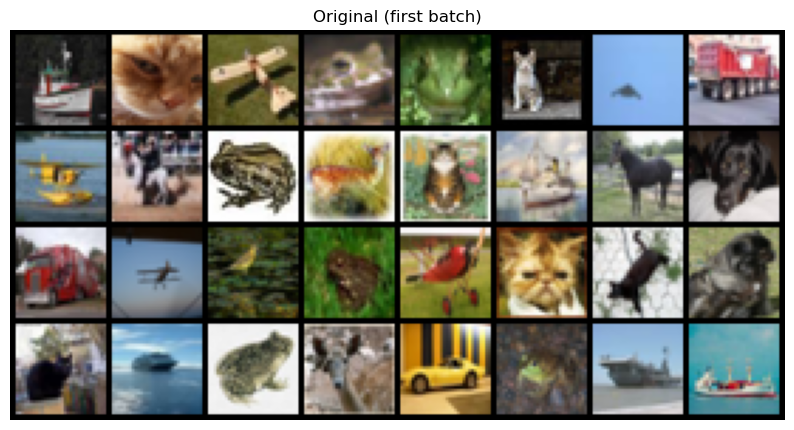

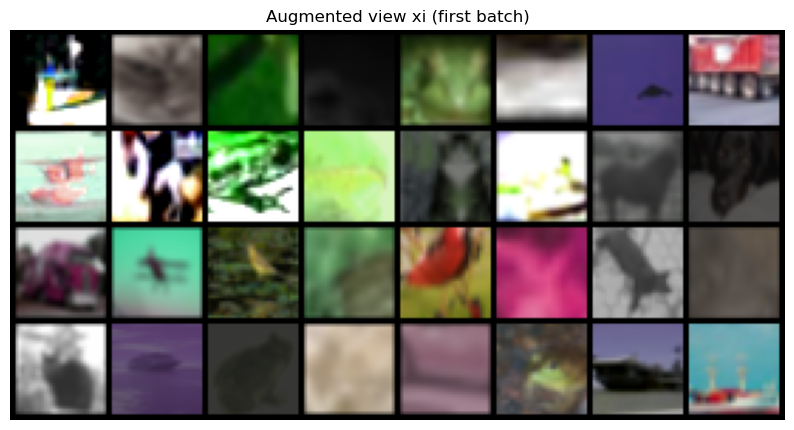

In [4]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def _to_imshow(grid: torch.Tensor) -> torch.Tensor:
    """(C,H,W) in [0,1] を想定して matplotlib 用に (H,W,C) にする。"""
    if grid.ndim != 3:
        raise ValueError(f"grid must be (C,H,W). got {tuple(grid.shape)}")
    return grid.detach().cpu().permute(1, 2, 0).clamp(0, 1)

for x, _ in dl:
    x0 = x
    xi = preprocess_image_batch(x=x, cfg=aug_cfg, is_training=True)
    break

n_show = min(32, x0.shape[0])
grid_org = make_grid(x0[:n_show], nrow=8, padding=2)
grid_aug = make_grid(xi[:n_show], nrow=8, padding=2)

# 3) 表示
plt.figure(figsize=(10, 10))
plt.title("Original (first batch)")
plt.axis("off")
plt.imshow(_to_imshow(grid_org))
plt.show()

plt.figure(figsize=(10, 10))
plt.title("Augmented view xi (first batch)")
plt.axis("off")
plt.imshow(_to_imshow(grid_aug))
plt.show()

### 学習の実行

In [ ]:
# Train
trainer = SimCLRTrainer(cfg=cfg, aug_cfg=aug_cfg, model=model, device=device)
hist = trainer.fit(dl)

train epoch 0001:   0%|          | 0/195 [00:07<?, ?it/s]

### 学習済みのEncoderを用いて特徴抽出＆線形分類器で評価

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Encoder を取得（projection head は捨てて encoder のみ使用）
encoder = trainer.model.encoder
encoder.eval()

train_ds = CIFAR10(root="data", train=True, download=True, transform=ToTensor())
test_ds = CIFAR10(root="data", train=False, download=True, transform=ToTensor())

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
)

# 特徴抽出
def extract_features(
    *,
    encoder: torch.nn.Module,
    loader: DataLoader, # type: ignore
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    """encoder で特徴抽出して sklearn 用の (X, y) を返す。"""
    encoder.eval()

    xs: list[np.ndarray] = []
    ys: list[np.ndarray] = []

    for x, y in loader:
        if not isinstance(x, torch.Tensor) or not isinstance(y, torch.Tensor):
            raise TypeError("DataLoader は (torch.Tensor, torch.Tensor) を返す想定です。")

        x = x.to(device, non_blocking=True)
        z = encoder(x)  # (B, D)
        z_np = z.detach().to("cpu", dtype=torch.float32).numpy()

        xs.append(z_np)
        ys.append(y.detach().to("cpu").numpy())

    X = np.concatenate(xs, axis=0).astype(np.float32, copy=False)
    Y = np.concatenate(ys, axis=0).astype(np.int64, copy=False)
    return X, Y

X_train, y_train = extract_features(encoder=encoder, loader=train_loader, device=device)
X_test, y_test = extract_features(encoder=encoder, loader=test_loader, device=device)

clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="multinomial",
    n_jobs=-1,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Top1 Acc in test dataset:", acc)